In [5]:

import itertools
from dataclasses import dataclass
import pulp
import matplotlib.pyplot as plt
from typing import Dict, List, Tuple, Optional
import time
import statistics
import pandas as pd


@dataclass
class Instance:
    name: str
    jobs_ops: Dict[int, List[Tuple[int, int]]]  

    def all_ops(self):
        return [Operation(i, k+1, mk, p) for i, seq in self.jobs_ops.items() for k, (mk,p) in enumerate(seq)]
    def machines(self):
        return sorted({mk for seq in self.jobs_ops.values() for (mk,_) in seq})
    def horizon(self):
        return sum(p for seq in self.jobs_ops.values() for (_,p) in seq)

JSSP1 = Instance("JSSP1_8x6", {
    1: [(1,10),(2,32),(3,21),(4,40),(5,53),(6,23)],
    2: [(2,35),(1,0),(3,29),(4,51),(5,48),(6,20)],
    3: [(4,54),(1,0),(5,53),(3,0),(6,21),(2,0)],
    4: [(3,38),(2,23),(4,65),(5,61),(6,21),(1,0)],
    5: [(1,15),(2,30),(3,31),(4,54),(5,53),(6,18)],
    6: [(1,16),(2,25),(3,17),(4,68),(5,64),(6,0)],
    7: [(4,54),(1,0),(5,53),(3,0),(6,21),(2,0)],
    8: [(2,28),(1,16),(3,22),(4,55),(5,59),(6,20)],
})
JSSP2 = Instance("JSSP2_6x6", {
    1: [(3,25),(1,12),(2,18),(4,56),(6,23),(5,65)],
    2: [(2,20),(3,32),(5,67),(6,24),(1,13),(4,46)],
    3: [(3,21),(4,43),(6,19),(1,10),(2,23),(5,55)],
    4: [(2,24),(1,15),(3,40),(4,61),(5,68),(6,21)],
    5: [(3,35),(2,27),(5,71),(6,19),(1,12),(4,55)],
    6: [(2,30),(4,65),(6,18),(1,15),(5,66),(3,35)],
})
JSSP3 = Instance("JSSP3_6x6", {
    1: [(3,21),(1,10),(2,32),(4,40),(6,23),(5,53)],
    2: [(2,15),(3,8),(5,61),(6,35),(1,14),(4,45)],
    3: [(3,21),(4,55),(6,22),(1,10),(2,30),(5,58)],
    4: [(2,34),(1,9),(3,19),(4,50),(5,52),(6,20)],
    5: [(3,23),(2,35),(5,63),(6,25),(1,11),(4,48)],
    6: [(2,38),(4,41),(6,18),(1,10),(5,65),(3,43)],
})





# Instancias adicionales para robustez 

def scale_instance(base_inst: Instance, factor: float, new_name: str) -> Instance:
    """
    Crea una nueva instancia escalando los tiempos de proceso
    de la instancia base por un factor dado.
    Mantiene el mismo orden de máquinas y jobs.
    """
    new_jobs_ops = {}
    for j, ops in base_inst.jobs_ops.items():
        new_ops = []
        for m, p in ops:
            new_p = max(1, int(round(p * factor)))  # evitar tiempos 0
            new_ops.append((m, new_p))
        new_jobs_ops[j] = new_ops
    return Instance(new_name, new_jobs_ops)

INST_BASE = [JSSP1, JSSP2, JSSP3]

JSSP1_fast = scale_instance(JSSP1, 0.8, "JSSP1_fast")

JSSP2_slow = scale_instance(JSSP2, 1.2, "JSSP2_slow")

# Conjunto final de 5 instancias para robustez
INSTANCES_ROBUSTEZ = [JSSP1, JSSP2, JSSP3, JSSP1_fast, JSSP2_slow]


=== Resolviendo JSSP1_8x6 ===

=== Resolviendo JSSP2_6x6 ===

=== Resolviendo JSSP3_6x6 ===

=== JSSP1_8x6 — TU MODELO EXACTO (Big-M global) ===
Status: Optimal
Cmax : 505.0
  Máquina M1:
    J1-O1: start=0.0, finish=10.0, p=10
    J5-O1: start=27.0, finish=42.0, p=15
    J3-O2: start=54.0, finish=54.0, p=0
    J6-O1: start=54.0, finish=70.0, p=16
    J7-O2: start=108.0, finish=108.0, p=0
    J8-O2: start=108.0, finish=124.0, p=16
    J2-O2: start=228.0, finish=228.0, p=0
    J4-O6: start=465.0, finish=465.0, p=0
  Máquina M2:
    J1-O2: start=10.0, finish=42.0, p=32
    J5-O2: start=42.0, finish=72.0, p=30
    J8-O1: start=72.0, finish=100.0, p=28
    J4-O2: start=100.0, finish=123.0, p=23
    J6-O2: start=123.0, finish=148.0, p=25
    J2-O1: start=193.0, finish=228.0, p=35
    J3-O6: start=421.0, finish=421.0, p=0
    J7-O6: start=504.0, finish=504.0, p=0
  Máquina M3:
    J4-O1: start=0.0, finish=38.0, p=38
    J1-O3: start=42.0, finish=63.0, p=21
    J5-O3: start=77.0, finish=108.

C:\Users\alanw\AppData\Local\Temp\ipykernel_22816\3141784223.py:88: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('tab20')


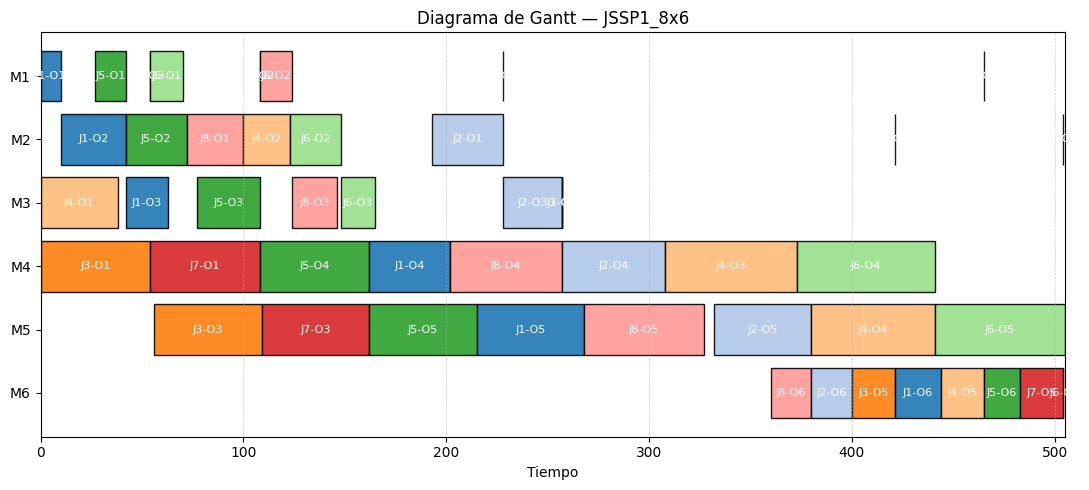


=== JSSP2_6x6 — TU MODELO EXACTO (Big-M global) ===
Status: Optimal
Cmax : 444.0
  Máquina M1:
    J1-O2: start=146.0, finish=158.0, p=12
    J4-O2: start=158.0, finish=173.0, p=15
    J6-O4: start=175.0, finish=190.0, p=15
    J3-O4: start=233.0, finish=243.0, p=10
    J2-O5: start=280.0, finish=293.0, p=13
    J5-O5: start=299.0, finish=311.0, p=12
  Máquina M2:
    J2-O1: start=0.0, finish=20.0, p=20
    J6-O1: start=38.0, finish=68.0, p=30
    J5-O2: start=92.0, finish=119.0, p=27
    J4-O1: start=134.0, finish=158.0, p=24
    J1-O3: start=158.0, finish=176.0, p=18
    J3-O5: start=243.0, finish=266.0, p=23
  Máquina M3:
    J2-O2: start=20.0, finish=52.0, p=32
    J5-O1: start=52.0, finish=87.0, p=35
    J1-O1: start=87.0, finish=112.0, p=25
    J3-O1: start=112.0, finish=133.0, p=21
    J4-O3: start=173.0, finish=213.0, p=40
    J6-O6: start=256.0, finish=291.0, p=35
  Máquina M4:
    J6-O2: start=68.0, finish=133.0, p=65
    J3-O2: start=133.0, finish=176.0, p=43
    J1-O4: sta

C:\Users\alanw\AppData\Local\Temp\ipykernel_22816\3141784223.py:88: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('tab20')


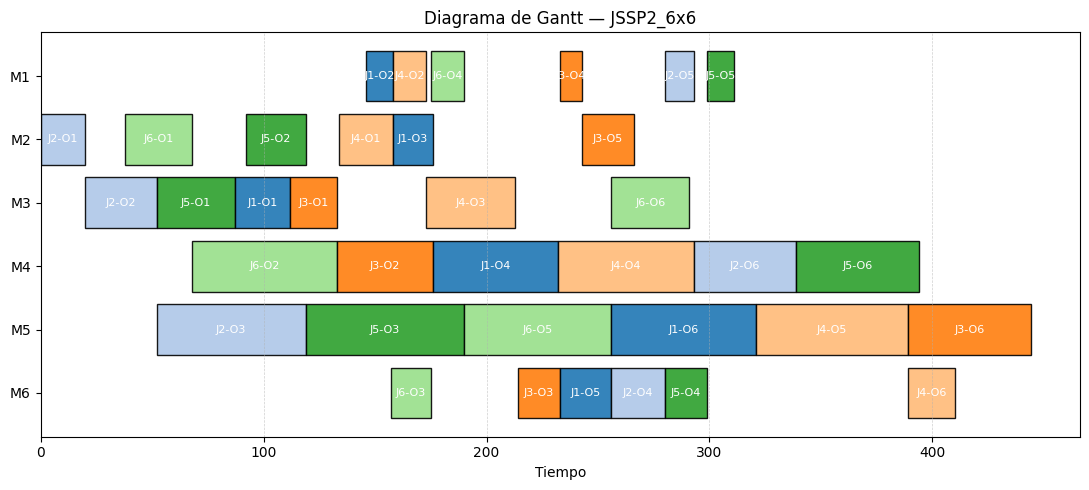


=== JSSP3_6x6 — TU MODELO EXACTO (Big-M global) ===
Status: Optimal
Cmax : 379.0
  Máquina M1:
    J1-O2: start=112.0, finish=122.0, p=10
    J4-O2: start=122.0, finish=131.0, p=9
    J6-O4: start=141.0, finish=151.0, p=10
    J3-O4: start=176.0, finish=186.0, p=10
    J2-O5: start=236.0, finish=250.0, p=14
    J5-O5: start=250.0, finish=261.0, p=11
  Máquina M2:
    J2-O1: start=0.0, finish=15.0, p=15
    J6-O1: start=15.0, finish=53.0, p=38
    J5-O2: start=53.0, finish=88.0, p=35
    J4-O1: start=88.0, finish=122.0, p=34
    J1-O3: start=122.0, finish=154.0, p=32
    J3-O5: start=186.0, finish=216.0, p=30
  Máquina M3:
    J2-O2: start=15.0, finish=23.0, p=8
    J5-O1: start=30.0, finish=53.0, p=23
    J3-O1: start=53.0, finish=74.0, p=21
    J1-O1: start=74.0, finish=95.0, p=21
    J4-O3: start=131.0, finish=150.0, p=19
    J6-O6: start=216.0, finish=259.0, p=43
  Máquina M4:
    J6-O2: start=53.0, finish=94.0, p=41
    J3-O2: start=99.0, finish=154.0, p=55
    J1-O4: start=154.0,

C:\Users\alanw\AppData\Local\Temp\ipykernel_22816\3141784223.py:88: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('tab20')


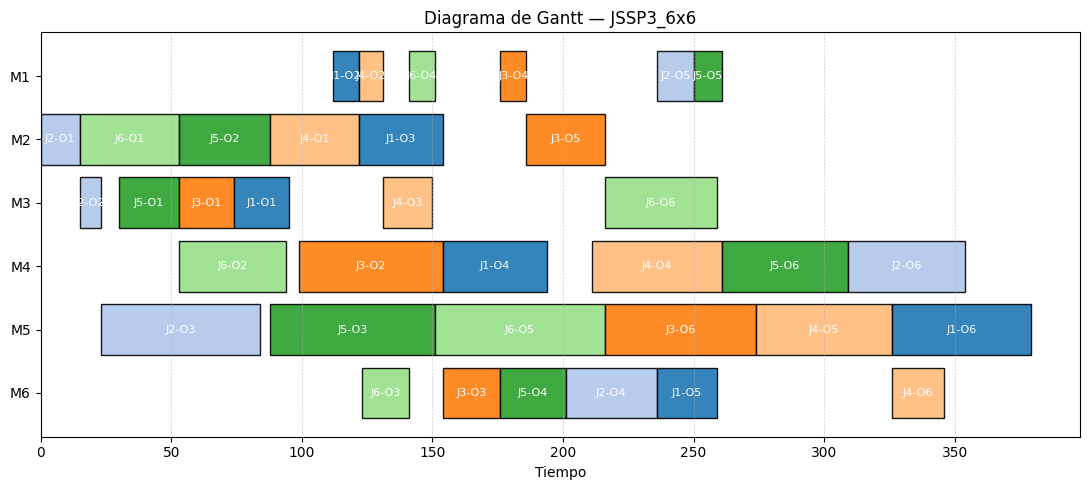

In [6]:
# MIP

@dataclass
class Operation:
    job: int
    idx: int        
    machine: int
    proc: int       


# MODELO EXACTO

def solve_tu_modelo_exacto(instance: Instance, timelimit_seconds=180, msg=False):
    ops = instance.all_ops()
    op_by_ik = {(op.job, op.idx): op for op in ops}
    machines = instance.machines()
    H = sum(p for seq in instance.jobs_ops.values() for (_, p) in seq)
    M = H

    pairs = []
    iks = [(op.job, op.idx) for op in ops]
    for a, b in itertools.combinations(iks, 2):
        if op_by_ik[a].machine == op_by_ik[b].machine:
            pairs.append((a, b))

    model = pulp.LpProblem(f"JSSP_{instance.name}_TU_MODELO_EXACTO", pulp.LpMinimize)

    # Variables
    S = pulp.LpVariable.dicts("S", iks, lowBound=0, cat=pulp.LpContinuous)
    C = pulp.LpVariable.dicts("C", iks, lowBound=0, cat=pulp.LpContinuous)
    Cmax = pulp.LpVariable("C_max", lowBound=0, cat=pulp.LpContinuous)
    y = pulp.LpVariable.dicts("y", pairs, lowBound=0, upBound=1, cat=pulp.LpBinary)

    model += Cmax


    for i, seq in instance.jobs_ops.items():
        for k in range(1, len(seq)):
            model += S[(i, k+1)] >= C[(i, k)], f"prec_{i}_{k}_to_{k+1}"

    for (i, k), op in op_by_ik.items():
        model += C[(i, k)] == S[(i, k)] + op.proc, f"defC_{i}_{k}"

    # Cap máq
    for (ij, pq) in pairs:
        i, k = ij
        p, q = pq
        model += S[(i, k)] >= C[(p, q)] - M * (1 - y[(ij, pq)]), f"disj_a_{i}_{k}__{p}_{q}"
        model += S[(p, q)] >= C[(i, k)] - M * y[(ij, pq)], f"disj_b_{i}_{k}__{p}_{q}"

    # Makespan
    for (i, k) in iks:
        model += Cmax >= C[(i, k)], f"mk_{i}_{k}"

    # Resolver
    solver = pulp.PULP_CBC_CMD(msg=msg, timeLimit=timelimit_seconds)
    status_code = model.solve(solver)
    status = pulp.LpStatus[status_code]
    Cmax_val = pulp.value(Cmax)

    # Cronograma
    schedule = {m: [] for m in machines}
    for (i, k), op in op_by_ik.items():
        st = pulp.value(S[(i, k)])
        ft = pulp.value(C[(i, k)])
        schedule[op.machine].append({"job": i, "op": k, "start": st, "finish": ft, "p": op.proc})
    for m in schedule:
        schedule[m].sort(key=lambda r: r["start"] if r["start"] is not None else 1e18)

    return status, Cmax_val, schedule


###########

def pretty_print(instance_name, status, Cmax, schedule):
    print(f"\n=== {instance_name} — TU MODELO EXACTO (Big-M global) ===")
    print(f"Status: {status}")
    print(f"Cmax : {Cmax}")
    for m in sorted(schedule.keys()):
        print(f"  Máquina M{m}:")
        for r in schedule[m]:
            print(f"    J{r['job']}-O{r['op']}: start={r['start']:.1f}, finish={r['finish']:.1f}, p={r['p']}")

############

def plot_gantt(instance_name, schedule, save_path=None):
    fig, ax = plt.subplots(figsize=(11, 5))
    cmap = plt.cm.get_cmap('tab20')

    machines = sorted(schedule.keys())
    yticks, ylabels = [], []

    for row, m in enumerate(machines):
        yticks.append(row)
        ylabels.append(f"M{m}")
        for op in schedule[m]:
            i   = op["job"]
            k   = op["op"]
            st  = op["start"]
            ft  = op["finish"]
            dur = (ft - st) if (st is not None and ft is not None) else None
            if dur is None:
                continue
            ax.barh(row, dur, left=st, edgecolor='black',
                    color=cmap((i-1) % 20), alpha=0.9)
            ax.text(st + dur/2, row, f"J{i}-O{k}",
                    va='center', ha='center', fontsize=8, color='white')

    ax.set_yticks(yticks)
    ax.set_yticklabels(ylabels)
    ax.set_xlabel("Tiempo")
    ax.set_title(f"Diagrama de Gantt — {instance_name}")
    ax.invert_yaxis()
    ax.grid(True, axis='x', linestyle='--', linewidth=0.5, alpha=0.6)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches='tight')
    plt.show()


#########

def run_all(instances=None, timelimit_seconds=180, msg=False, save_pngs=True, show_plots=True):
    if instances is None:
        instances = [JSSP1, JSSP2, JSSP3]

    results = {}
    for inst in instances:
        print(f"\n=== Resolviendo {inst.name} ===")
        status, Cmax, sched = solve_tu_modelo_exacto(inst, timelimit_seconds=timelimit_seconds, msg=msg)
        results[inst.name] = (status, Cmax, sched)

    for inst in instances:
        status, Cmax, sched = results[inst.name]
        pretty_print(inst.name, status, Cmax, sched)
        if save_pngs:
            plot_gantt(inst.name, sched, save_path=f"gantt_{inst.name}.png")
        elif show_plots:
            plot_gantt(inst.name, sched, save_path=None)


if __name__ == "__main__":
    run_all(
        instances=[JSSP1, JSSP2, JSSP3],
        timelimit_seconds=180,
        msg=False,
        save_pngs=True,   
        show_plots=True   
    )



====== EXPERIMENTO MAS — JSSP1_8x6 ======
  → Repetición 1: Cmax=522.0, Tiempo=0.0000s, Política=SMART
  → Repetición 2: Cmax=522.0, Tiempo=0.0000s, Política=SMART
  → Repetición 3: Cmax=522.0, Tiempo=0.0011s, Política=SMART
  → Repetición 4: Cmax=522.0, Tiempo=0.0000s, Política=SMART
  → Repetición 5: Cmax=522.0, Tiempo=0.0000s, Política=SMART
  → Repetición 6: Cmax=522.0, Tiempo=0.0000s, Política=SMART
  → Repetición 7: Cmax=522.0, Tiempo=0.0000s, Política=SMART
  → Repetición 8: Cmax=522.0, Tiempo=0.0013s, Política=SMART
  → Repetición 9: Cmax=522.0, Tiempo=0.0000s, Política=SMART
  → Repetición 10: Cmax=522.0, Tiempo=0.0000s, Política=SMART

--- RESULTADOS FINALES ---
Política usada: SMART
Mejor Cmax obtenido: 522.0
Promedio de Cmax: 522.00 (σ=0.00)
Promedio de tiempo: 0.0002s (σ=0.0005)

=== JSSP1_8x6 — MAS ===
Cmax (MAS): 522.0
  Máquina M1:
    J1-O1: start=0.0, finish=10.0, p=10
    J3-O2: start=54.0, finish=54.0, p=0
    J2-O2: start=54.0, finish=54.0, p=0
    J7-O2: start=1

C:\Users\alanw\AppData\Local\Temp\ipykernel_22816\932736695.py:229: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('tab20', 20)


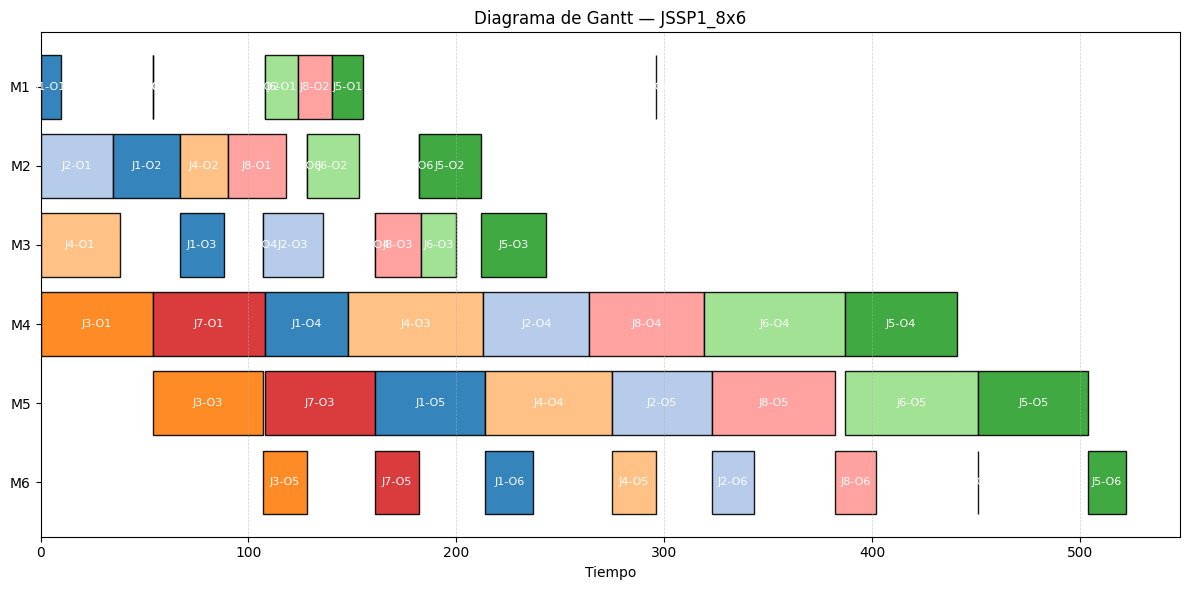



====== EXPERIMENTO MAS — JSSP2_6x6 ======
  → Repetición 1: Cmax=468.0, Tiempo=0.0000s, Política=SMART
  → Repetición 2: Cmax=468.0, Tiempo=0.0000s, Política=SMART
  → Repetición 3: Cmax=468.0, Tiempo=0.0000s, Política=SMART
  → Repetición 4: Cmax=468.0, Tiempo=0.0000s, Política=SMART
  → Repetición 5: Cmax=468.0, Tiempo=0.0000s, Política=SMART
  → Repetición 6: Cmax=468.0, Tiempo=0.0000s, Política=SMART
  → Repetición 7: Cmax=468.0, Tiempo=0.0000s, Política=SMART
  → Repetición 8: Cmax=468.0, Tiempo=0.0000s, Política=SMART
  → Repetición 9: Cmax=468.0, Tiempo=0.0000s, Política=SMART
  → Repetición 10: Cmax=468.0, Tiempo=0.0000s, Política=SMART

--- RESULTADOS FINALES ---
Política usada: SMART
Mejor Cmax obtenido: 468.0
Promedio de Cmax: 468.00 (σ=0.00)
Promedio de tiempo: 0.0000s (σ=0.0000)

=== JSSP2_6x6 — MAS ===
Cmax (MAS): 468.0
  Máquina M1:
    J4-O2: start=44.0, finish=59.0, p=15
    J3-O4: start=83.0, finish=93.0, p=10
    J2-O5: start=144.0, finish=157.0, p=13
    J6-O4: st

C:\Users\alanw\AppData\Local\Temp\ipykernel_22816\932736695.py:229: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('tab20', 20)


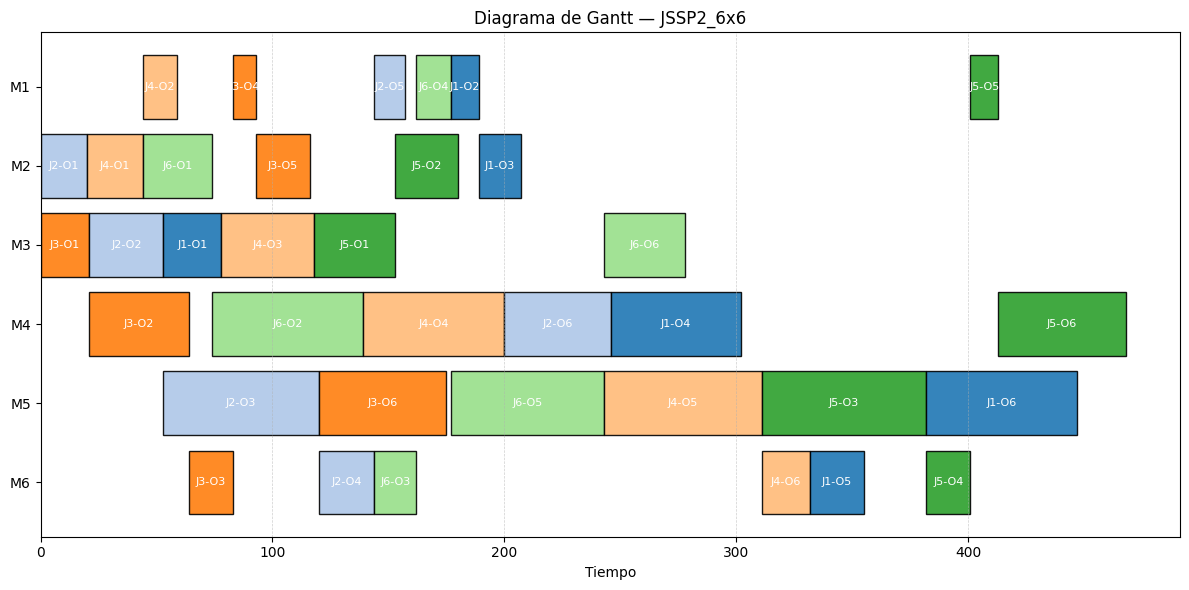



====== EXPERIMENTO MAS — JSSP3_6x6 ======
  → Repetición 1: Cmax=461.0, Tiempo=0.0000s, Política=SMART
  → Repetición 2: Cmax=461.0, Tiempo=0.0000s, Política=SMART
  → Repetición 3: Cmax=461.0, Tiempo=0.0000s, Política=SMART
  → Repetición 4: Cmax=461.0, Tiempo=0.0000s, Política=SMART
  → Repetición 5: Cmax=461.0, Tiempo=0.0000s, Política=SMART
  → Repetición 6: Cmax=461.0, Tiempo=0.0000s, Política=SMART
  → Repetición 7: Cmax=461.0, Tiempo=0.0000s, Política=SMART
  → Repetición 8: Cmax=461.0, Tiempo=0.0000s, Política=SMART
  → Repetición 9: Cmax=461.0, Tiempo=0.0000s, Política=SMART
  → Repetición 10: Cmax=461.0, Tiempo=0.0000s, Política=SMART

--- RESULTADOS FINALES ---
Política usada: SMART
Mejor Cmax obtenido: 461.0
Promedio de Cmax: 461.00 (σ=0.00)
Promedio de tiempo: 0.0000s (σ=0.0000)

=== JSSP3_6x6 — MAS ===
Cmax (MAS): 461.0
  Máquina M1:
    J1-O2: start=21.0, finish=31.0, p=10
    J4-O2: start=49.0, finish=58.0, p=9
    J2-O5: start=125.0, finish=139.0, p=14
    J6-O4: sta

C:\Users\alanw\AppData\Local\Temp\ipykernel_22816\932736695.py:229: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('tab20', 20)


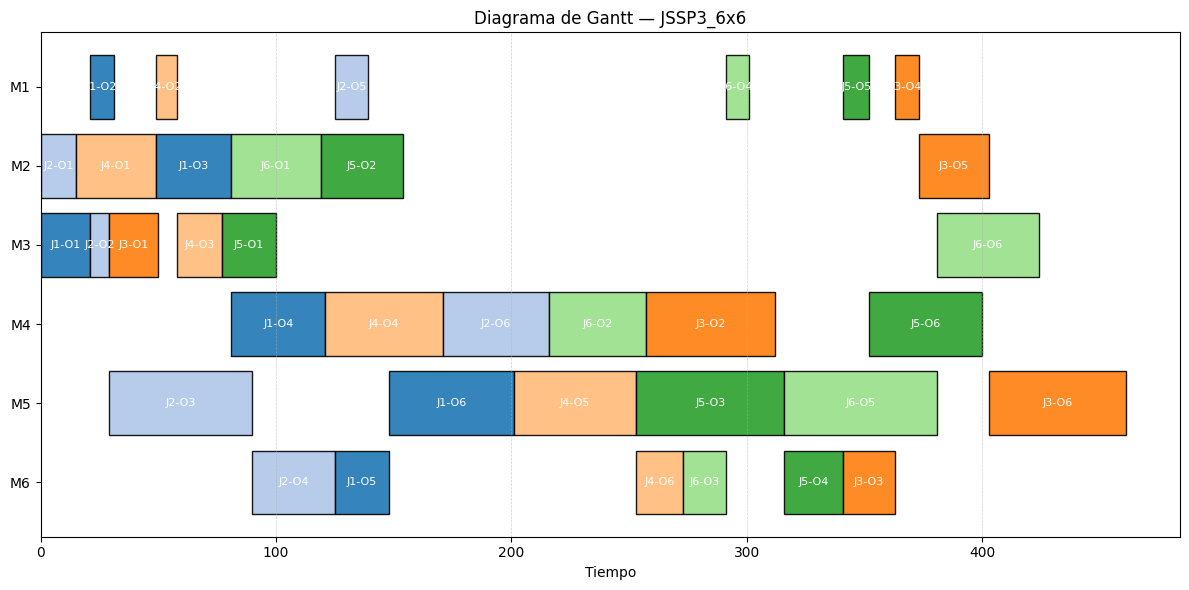

In [7]:
#MAS

@dataclass
class Operation:
    job: int
    idx: int
    machine: int
    proc: int

@dataclass
class Instance:
    name: str
    jobs_ops: Dict[int, List[Tuple[int, int]]]

    def all_ops(self) -> List[Operation]:
        return [
            Operation(i, k+1, mk, p)
            for i, seq in self.jobs_ops.items()
            for k, (mk, p) in enumerate(seq)
        ]

    def machines(self) -> List[int]:
        return sorted({mk for seq in self.jobs_ops.values() for (mk, _) in seq})

# AGENTES

class JobAgent:
    def __init__(self, job_id: int, ops_seq: List[Operation]):
        self.job = job_id
        self.sequence: List[Operation] = ops_seq
        self.remaining_proc: float = sum(op.proc for op in self.sequence)
        self.current_idx: int = 0
        self.ready_time: float = 0.0
        self.finished: bool = False

    def current_op(self) -> Optional[Operation]:
        if self.finished:
            return None
        if self.current_idx >= len(self.sequence):
            self.finished = True
            return None
        return self.sequence[self.current_idx]

    def act(self, machines: Dict[int, "MachineAgent"]):
        op = self.current_op()
        if op is None:
            return

        m = op.machine

        # No duplicar solicitudes
        if any((req_op.job == op.job and req_op.idx == op.idx) 
               for (req_op, _, _) in machines[m].inbox):
            return

        machines[m].receive_request(op, self.ready_time, self.remaining_proc)

    def mark_done(self, start: float, finish: float):
        dur = finish - start
        self.remaining_proc = max(0.0, self.remaining_proc - dur)

        self.ready_time = finish
        self.current_idx += 1
        if self.current_idx >= len(self.sequence):
            self.finished = True

class MachineAgent:
    def __init__(self, m_id: int, allowed_ops: List[Tuple[int, int]], policy: str = "SMART"):
        self.m = m_id
        self.allowed_ops = set(allowed_ops)
        self.policy = policy.upper()

        # parámetros SMART
        self.alpha = 1.0   # peso EST
        self.beta  = 0.2   # peso SPT
        self.gamma = 0.5   # peso RemainingProc

        self.available_from: float = 0.0
        self.inbox: List[Tuple[Operation, float, float]] = []
        self.schedule: List[Tuple[int, int, float, float, int]] = []

    def receive_request(self, op: Operation, ready_time: float, remaining_proc: float):
        key = (op.job, op.idx)
        if key not in self.allowed_ops:
            return
        self.inbox.append((op, ready_time, remaining_proc))

    def decide(self) -> Optional[Tuple[int, int, float, float, int]]:
        if not self.inbox:
            return None

        best_idx = None
        best_key = None
        best_op = None
        best_start = None

        for idx, (op, rdy, rem) in enumerate(self.inbox):
            est = max(self.available_from, rdy)
            p = op.proc

            # ---------- POLÍTICA SMART ----------
            key_value = (
                self.alpha * est +
                self.beta  * p +
                self.gamma * rem
            )

            if (best_key is None) or (key_value < best_key):
                best_key = key_value
                best_idx = idx
                best_op = op
                best_start = est

        if best_op is None:
            return None

        # retiramos del inbox
        self.inbox.pop(best_idx)

        start = best_start
        finish = start + best_op.proc

        self.available_from = finish
        self.schedule.append((best_op.job, best_op.idx, start, finish, best_op.proc))

        return (best_op.job, best_op.idx, start, finish, best_op.proc)

# SMART

def mas_schedule(instance: Instance, policy="SMART"):
    Ms = instance.machines()

    jobs: Dict[int, JobAgent] = {}
    allowed_ops_per_machine: Dict[int, List[Tuple[int, int]]] = {m: [] for m in Ms}

    for i, seq in instance.jobs_ops.items():
        ops_list: List[Operation] = []
        for k, (mk, p) in enumerate(seq, start=1):
            op = Operation(i, k, mk, p)
            ops_list.append(op)
            allowed_ops_per_machine[mk].append((i, k))
        jobs[i] = JobAgent(i, ops_list)

    machines: Dict[int, MachineAgent] = {
        m: MachineAgent(
            m_id=m,
            allowed_ops=allowed_ops_per_machine[m],
            policy=policy
        )
        for m in Ms
    }

    total_ops = sum(len(seq) for seq in instance.jobs_ops.values())
    scheduled_ops = 0

    while scheduled_ops < total_ops:
        for J in jobs.values():
            J.act(machines)

        progressed = False
        for M in machines.values():
            res = M.decide()
            if res is not None:
                j, k, start, finish, p = res
                jobs[j].mark_done(start, finish)
                scheduled_ops += 1
                progressed = True

        if not progressed:
            if not any(not j.finished for j in jobs.values()):
                break

    schedule = {m: list(machines[m].schedule) for m in Ms}
    Cmax = max(ft for ops in schedule.values() for (_, _, _, ft, _) in ops)
    return schedule, Cmax

#############

def run_experiment(instance, repetitions=10):
    cmax_list = []
    time_list = []
    best_cmax_run = None
    best_sched_run = None

    for r in range(repetitions):
        start = time.time()
        sched, cmax = mas_schedule(instance, policy="SMART")
        end = time.time()

        elapsed = end - start
        cmax_list.append(cmax)
        time_list.append(elapsed)

        if (best_cmax_run is None) or (cmax < best_cmax_run):
            best_cmax_run = cmax
            best_sched_run = sched

        print(f"  → Repetición {r+1}: Cmax={cmax}, Tiempo={elapsed:.4f}s, Política=SMART")

    avg_cmax = statistics.mean(cmax_list)
    avg_time = statistics.mean(time_list)
    std_cmax = statistics.pstdev(cmax_list)
    std_time = statistics.pstdev(time_list)

    return {
        "cmax_list": cmax_list,
        "time_list": time_list,
        "avg_cmax": avg_cmax,
        "avg_time": avg_time,
        "std_cmax": std_cmax,
        "std_time": std_time,
        "best_cmax": best_cmax_run,
        "best_sched": best_sched_run,
        "best_policy": "SMART",
    }

##############

def pretty_print(instance_name, schedule, Cmax):
    print(f"\n=== {instance_name} — MAS ===")
    print(f"Cmax (MAS): {Cmax:.1f}")
    for m in sorted(schedule.keys()):
        print(f"  Máquina M{m}:")
        for (j, k, st, ft, p) in schedule[m]:
            print(f"    J{j}-O{k}: start={st:.1f}, finish={ft:.1f}, p={p}")

def plot_gantt(instance_name, schedule, save_path=None):
    fig, ax = plt.subplots(figsize=(12, 6))
    cmap = plt.cm.get_cmap('tab20', 20)
    machines = sorted(schedule.keys())

    for row, m in enumerate(machines):
        for (j, k, st, ft, p) in schedule[m]:
            ax.barh(row, ft - st, left=st, edgecolor='black', color=cmap((j - 1) % 20), alpha=0.9)
            ax.text(st + (ft - st)/2, row, f"J{j}-O{k}",
                    va='center', ha='center', fontsize=8, color='white')

    ax.set_yticks(range(len(machines)))
    ax.set_yticklabels([f"M{m}" for m in machines])
    ax.set_xlabel("Tiempo")
    ax.set_title(f"Diagrama de Gantt — {instance_name}")
    ax.invert_yaxis()
    ax.grid(True, axis='x', linestyle='--', linewidth=0.5, alpha=0.6)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches='tight')
    plt.show()

#############

if __name__ == "__main__":
    for inst in [JSSP1, JSSP2, JSSP3]:
        print(f"\n\n====== EXPERIMENTO MAS — {inst.name} ======")

        results = run_experiment(inst, repetitions=10)

        print("\n--- RESULTADOS FINALES ---")
        print(f"Política usada: SMART")
        print(f"Mejor Cmax obtenido: {results['best_cmax']}")
        print(f"Promedio de Cmax: {results['avg_cmax']:.2f} (σ={results['std_cmax']:.2f})")
        print(f"Promedio de tiempo: {results['avg_time']:.4f}s (σ={results['std_time']:.4f})")

        pretty_print(inst.name, results['best_sched'], results['best_cmax'])
        plot_gantt(inst.name, results['best_sched'], save_path=f"gantt_MAS_{inst.name}.png")


In [10]:
import statistics as stats

def benchmark_instance(instance: Instance, mas_reps: int = 5,
                       timelimit_seconds: int = 180, msg: bool = False):
    """
    Corre MIP una vez y MAS mas_reps veces sobre una instancia dada.
    Devuelve un diccionario con métricas de makespan, tiempo y GAP.
    """
    # --- MIP (una corrida, óptimo de referencia) ---
    t0 = time.time()
    status, C_mip, sched_mip = solve_tu_modelo_exacto(
        instance,
        timelimit_seconds=timelimit_seconds,
        msg=msg
    )
    t1 = time.time()
    mip_time = t1 - t0

    if status != 1:
        print(f"[WARN] MIP no alcanzó solución óptima en {instance.name} (status={status})")

    cmas_list = []
    tmas_list = []
    sched_mas_example = None

    for r in range(mas_reps):
        t2 = time.time()
        sched_mas, C_mas = mas_schedule(instance, policy="SMART")
        t3 = time.time()

        cmas_list.append(C_mas)
        tmas_list.append(t3 - t2)

        if sched_mas_example is None:
            sched_mas_example = sched_mas

    C_mas_mean = stats.mean(cmas_list)
    C_mas_std = stats.pstdev(cmas_list) if len(cmas_list) > 1 else 0.0

    t_mas_mean = stats.mean(tmas_list)
    t_mas_std = stats.pstdev(tmas_list) if len(tmas_list) > 1 else 0.0

    gap_mean = (C_mas_mean - C_mip) / C_mip * 100 if C_mip > 0 else float("nan")

    return {
        "instancia": instance.name,
        "Cmax_MIP": C_mip,
        "Cmax_MAS_prom": C_mas_mean,
        "Cmax_MAS_std": C_mas_std,
        "GAP_prom_%": gap_mean,
        "t_MIP_seg": mip_time,
        "t_MAS_prom_seg": t_mas_mean,
        "t_MAS_std_seg": t_mas_std,
        "reps_MAS": mas_reps,
        "sched_MIP": sched_mip,
        "sched_MAS_ejemplo": sched_mas_example,
    }


In [11]:
resultados = []

for inst in INSTANCES_ROBUSTEZ:
    print(f"\n=== Bench {inst.name} ===")
    res = benchmark_instance(inst, mas_reps=5, timelimit_seconds=180, msg=False)
    resultados.append(res)
    print(f"  Cmax MIP         : {res['Cmax_MIP']}")
    print(f"  Cmax MAS (prom)  : {res['Cmax_MAS_prom']:.2f} (std={res['Cmax_MAS_std']:.2f})")
    print(f"  GAP prom         : {res['GAP_prom_%']:.2f}%")
    print(f"  t MIP            : {res['t_MIP_seg']:.4f} s")
    print(f"  t MAS (prom)     : {res['t_MAS_prom_seg']:.6f} s (std={res['t_MAS_std_seg']:.6f})")

df_resultados = pd.DataFrame(resultados)
df_resultados



=== Bench JSSP1_8x6 ===
[WARN] MIP no alcanzó solución óptima en JSSP1_8x6 (status=Optimal)
  Cmax MIP         : 505.0
  Cmax MAS (prom)  : 522.00 (std=0.00)
  GAP prom         : 3.37%
  t MIP            : 180.1875 s
  t MAS (prom)     : 0.000238 s (std=0.000475)

=== Bench JSSP2_6x6 ===
[WARN] MIP no alcanzó solución óptima en JSSP2_6x6 (status=Optimal)
  Cmax MIP         : 444.0
  Cmax MAS (prom)  : 468.00 (std=0.00)
  GAP prom         : 5.41%
  t MIP            : 1.6391 s
  t MAS (prom)     : 0.000000 s (std=0.000000)

=== Bench JSSP3_6x6 ===
[WARN] MIP no alcanzó solución óptima en JSSP3_6x6 (status=Optimal)
  Cmax MIP         : 379.0
  Cmax MAS (prom)  : 461.00 (std=0.00)
  GAP prom         : 21.64%
  t MIP            : 1.3460 s
  t MAS (prom)     : 0.000237 s (std=0.000473)

=== Bench JSSP1_fast ===
[WARN] MIP no alcanzó solución óptima en JSSP1_fast (status=Optimal)
  Cmax MIP         : 404.0
  Cmax MAS (prom)  : 416.00 (std=0.00)
  GAP prom         : 2.97%
  t MIP            :

,instancia,Cmax_MIP,Cmax_MAS_prom,Cmax_MAS_std,GAP_prom_%,t_MIP_seg,t_MAS_prom_seg,t_MAS_std_seg,reps_MAS,sched_MIP,sched_MAS_ejemplo
0,JSSP1_8x6,505.0,522.0,0.0,3.366337,180.187547,0.000238,0.000475,5,"{1: [{'job': 1, 'op': 1, 'start': 0.0, 'finish...","{1: [(1, 1, 0.0, 10.0, 10), (3, 2, 54.0, 54.0,..."
1,JSSP2_6x6,444.0,468.0,0.0,5.405405,1.639080,0.000000,0.000000,5,"{1: [{'job': 1, 'op': 2, 'start': 146.0, 'fini...","{1: [(4, 2, 44.0, 59.0, 15), (3, 4, 83.0, 93.0..."
2,JSSP3_6x6,379.0,461.0,0.0,21.635884,1.345958,0.000237,0.000473,5,"{1: [{'job': 1, 'op': 2, 'start': 112.0, 'fini...","{1: [(1, 2, 21.0, 31.0, 10), (4, 2, 49.0, 58.0..."
3,JSSP1_fast,404.0,416.0,0.0,2.970297,180.219119,0.000000,0.000000,5,"{1: [{'job': 5, 'op': 1, 'start': 0.0, 'finish...","{1: [(1, 1, 0.0, 8.0, 8), (3, 2, 43.0, 44.0, 1..."
4,JSSP2_slow,532.0,561.0,0.0,5.451128,2.375440,0.000000,0.000000,5,"{1: [{'job': 4, 'op': 2, 'start': 116.0, 'fini...","{1: [(4, 2, 53.0, 71.0, 18), (3, 4, 100.0, 112..."
